# 最尤推定を用いた二項ロジスティック回帰

書籍においては、二項ロジスティック回帰のモデリングにベイズ推定（ベイズ統計モデリング）を用いていました。これはベイズ推定出ないとモデリングできないことを意味するわけではなく、Statsmodelsを用いた最尤推定でもモデリング可能です。

この最尤推定を用いた二項ロジスティック回帰による異常検知を、Python（Statsmodels）を用いて以下の手順で実装する方法を解説します。

- A. 説明変数の選択
- B. モデルの学習
- C. 推論

なおデータセットにはベイズ推定（[ch8_5_Binomial_Logistic_Regression.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch8_5_Binomial_Logistic_Regression.ipynb)）と同じバスケットボールのスリーポイントシュート成功率のデータを、ターゲットとする誤報率としては0.0027を採用します。

使用するデータの例を以下に再掲します。

```csv
PLAYER_ID,AGE,FG3M,FG3A
203932,23.0,121,347
1628988,22.0,43,127
1627846,25.0,32,100
201143,33.0,73,203
202329,28.0,96,280
:
```

`PLAYER_ID`列が各選手を表すID、`AGE`列が年齢、`FG3A`列がスリーポイントシュート試投数$n$、`FG3M`列が成功数$x$を表しており、2022年度のデータを学習用、2023年度のデータを推論用として用います。

## A. 説明変数の選択

ベイズ推定を用いた二項ロジスティック回帰モデル（[ch8_5_Binomial_Logistic_Regression.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch8_5_Binomial_Logistic_Regression.ipynb)）と同様のため、省略します。

年齢と成功率には相関があるという分析に基づき、年齢を説明変数$x$、スリーポイントシュートの試投数（試行数）を$n$、成功数を$y$として以下のような二項ロジスティック回帰モデルを構築します。

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
&\eta=w_1 x+w_0  \nonumber \\
&\rm{logit}(\mu)=\eta  \nonumber \\
&p(y \mid n, x, w_1, w_0) = Bi(n,\mu)
\end{align}
" />

## B. モデルの学習

二項ロジスティック回帰モデルの最尤推定による学習を実施します（二項ロジスティック回帰ではしきい値の算出に推論データの説明変数$\boldsymbol{x}$および試行数$n$が必要となるため、学習段階ではしきい値算出を実施しません）。

statsmodelsで確率分布やリンク関数をカスタマイズしながらGLMを実装するには、[statsmodels.genmod.generalized_linear_model.GLM](https://www.statsmodels.org/stable/generated/statsmodels.genmod.generalized_linear_model.GLM.html)クラスを使用し、`family`引数に確率分布やリンク関数を指定するクラスを渡します。確率分布は[statsmodels.genmod.families.family](https://www.statsmodels.org/stable/glm.html#families)から、リンク関数は[statsmodels.genmod.families.links](https://www.statsmodels.org/stable/glm.html#link-functions)から該当するクラスを選択します。

In [ ]:
# 最尤推定による二項ロジスティック回帰の実装例（学習）
import pandas as pd
import numpy as np
import statsmodels.api as sm

###### 学習データの読み込みと前処理######
# スリーポイントシュート成功率データ
df_train = pd.read_csv('./../datasets/player_stats_2022.csv')
df_train = df_train[df_train['FG3A'] > 0] # 試投数0を除外
# 学習データの説明変数x、応答変数y、試行数nを別々に保持してndarray化
x_train = df_train['AGE'].to_numpy()
y_train = df_train['FG3M'].to_numpy()
n_train = df_train['FG3A'].to_numpy()

###### 学習ステップ1. 正常のモデルを作成する######
Y_train = np.column_stack((y_train, n_train - y_train)) # 成功数と失敗数を列に持つ2次元配列を作成
X_train_intercept = sm.add_constant(x_train) # 切片を追加
family=sm.families.Binomial() # 確率分布（二項分布）を指定
mod = sm.GLM(Y_train, X_train_intercept, family=family) # 二項ロジスティック回帰モデルを作成
res = mod.fit() # モデルの学習を実行

###### 学習ステップ2. 異常を表す指標（異常度）を定義する######
# 式を定義するのみでプログラム上は処理を実施しない

###### 学習ステップ3. 異常度にしきい値を設ける######
# 学習段階ではしきい値を求めない



###### 学習で求めたパラメータをすべて表示######
w_0 = res.params[mod.exog_names.index('const')]
w_1 = res.params[mod.exog_names.index('x1')]
print(f'w_1={w_1}')
print(f'w_0={w_0}')

# 学習結果のサマリーの表示
print(res.summary())

w_1=0.007148634496985046
w_0=-0.7937254211071707
                 Generalized Linear Model Regression Results                  
Dep. Variable:           ['y1', 'y2']   No. Observations:                  561
Model:                            GLM   Df Residuals:                      559
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1657.1
Date:                Sun, 02 Nov 2025   Deviance:                       880.42
Time:                        21:53:40   Pearson chi2:                     821.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.03243
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
con

パラメータの推定値（切片$w_0$に相当する`const`および傾き$w_1$に相当する`x1`）が、ベイズ推定（[ch8_5_Binomial_Logistic_Regression.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch8_5_Binomial_Logistic_Regression.ipynb)）の事後分布の平均とほぼ等しくなっていることが分かります。

説明変数（年齢）$x$と成功確率$\mu$の予測値との関係をプロットしてみます。

In [14]:
print(res.deviance)
print(res.df_resid)

880.4213071158442
559


<Axes: xlabel='AGE', ylabel='FG3_PCT'>

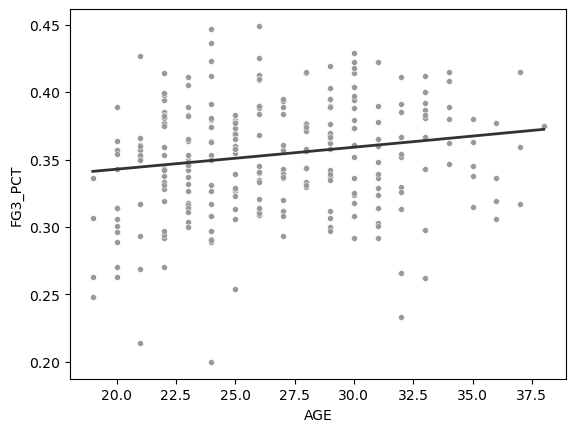

In [12]:
# 年齢xと成功確率μの予測値の関係を可視化
import seaborn as sns
import matplotlib.pyplot as plt

# 学習データから試投数100以上のみを抽出し、xとmu範囲を決定
df_train_a100over = df_train[df_train['FG3A'] > 100]
x_min, x_max = df_train_a100over['AGE'].min(), df_train_a100over['AGE'].max()
mu_min, mu_max = df_train_a100over['FG3_PCT'].min(), df_train_a100over['FG3_PCT'].max()
# muの推定値を計算してプロット
x_line = np.linspace(x_min, x_max, num=200)
rho_line = w_0 + w_1*x_line
mu_line = 1 / (1+np.exp(-rho_line))
plt.plot(x_line, mu_line, color='#333333', linewidth=2)
###### 学習データを散布図で描画 ######
sns.scatterplot(data=df_train_a100over,
                x='AGE', y='FG3_PCT',
                c='#999999', s=18, marker="o")

データにうまくフィットした予測ができていることが分かります。

## C. 推論

推論フェーズでは、学習フェーズで求めたパラメータ$w_1,w_0$、および推論データの試行数$n$、説明変数$\boldsymbol{x}$、応答変数$y$を用いて、以下の推論手順にしたがい異常判定を実施します。

- 学習で得たパラメータ$w_1,w_0$と推論データの説明変数$x$、試行数$n$から、モデル式に基づき予測分布を求める。
- 予測分布の分位点とターゲットとする誤報率に基づき、応答変数yの上下のしきい値を求める
- 推論データの応答変数$y$が、このしきい値の範囲外にあれば異常あり、範囲内にあれば異常なしと判定する
